In [2]:
# --- 1セルで実行してください ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

# ===== ここはあなたのクラス/CSVに合わせて =====
from ResultCalculator import SurveyResultAnalyzer
CSV_PATH = "./ResultData/SurvayResult.csv"
# =============== データ読み込み ===============
df = pd.read_csv(CSV_PATH)
survey = SurveyResultAnalyzer(df)
long_df = survey.to_long_scores()


# 一致した行だけ置換する
ABBR = {
    "SpatialReference": "SR",
    "SpatialReference+Pointing": "P+SR",
}
long_df["Condition"] = long_df["Condition"].replace(ABBR)
print(long_df["Condition"].unique())  # これで SR / P+SR / Pointing / Label が出ればOK

# 順序を略称に合わせて再定義
CONDITION_ORDER = ["SR", "P+SR", "Pointing", "Label"]
CONDITION_MAP = {1:"SR", 2:"P+SR", 3:"Pointing", 4:"Label"}

# =============== ユーティリティ ===============
def lists_by_condition(long_df, scale, subscale, labels=CONDITION_ORDER):
    """ロング形式から、labels順にデータ配列のリストを返す"""
    out = []
    q = (long_df["Scale"] == scale) & (long_df["Subscale"] == subscale)
    df = long_df[q]
    for lab in labels:
        out.append(df[df["Condition"] == lab]["Score"].tolist())
    return out

def boxplot_with_black_points(ax, data_lists, labels, title, ylabel,
                              cmap_name="Set2", y_headroom=0.08, y_pad=None):
    palette = [cm.get_cmap(cmap_name)(i) for i in range(len(labels))]
    bp = ax.boxplot(
        data_lists,
        labels=labels, 
      
        patch_artist=True,
        showfliers=True
    )
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(palette[i])
        patch.set_alpha(0.85)
        patch.set_edgecolor("black")
        patch.set_linewidth(1.2)
    for whisker in bp['whiskers']:
        whisker.set_color("black"); whisker.set_linewidth(1.2)
    for cap in bp['caps']:
        cap.set_color("black"); cap.set_linewidth(1.2)
    for median in bp['medians']:
        median.set_color("black"); median.set_linewidth(1.8)

    # 黒点（ジッタ）
    for i, ys in enumerate(data_lists, start=1):
        if len(ys) == 0:
            continue
        xs = np.random.normal(loc=i, scale=0.04, size=len(ys))
        ax.plot(xs, ys, marker='o', markersize=5, color='black', linestyle='None', alpha=0.8)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis='y', linestyle='--', alpha=0.35)

    # 上側の余白（比率 or 絶対値）
    ymin, ymax = ax.get_ylim()
    if y_pad is not None:
        ax.set_ylim(ymin, ymax + y_pad)
    else:
        ax.set_ylim(ymin, ymax + (ymax - ymin) * y_headroom)

def add_sig_brackets(
    ax,
    pairs_by_alpha,
    id_to_pos=None,
    star_map=None,                 # {"0.01":"**","0.05":"*"}
    top_pad_ratio=0.05,            # 図上端→最初のブラケットまで
    step_ratio=0.06,               # 段間
    tick_height_ratio=0.02,        # 縦棒高さ
    text_offset_ratio=-0.005,      # ブラケット上端→星の下端（負で重ね可）
    lw=1.2,
    star_fontsize=10,
    title_pad=4,
    alpha_priority=("0.05", "0.01"),
    allow_touch=True,
    pack_by="length",
    touch_gap=0.06,                # 同レベルで接している端点を左右に離す量（x座標単位）
    inner_pad=0.02,                # すべてのブラケットの左右に入れる微小インセット
    condition_map=None             # 🔧 追加: 数字→ラベル変換用
):
    import numpy as np

    if star_map is None:
        star_map = {"0.01": "**", "0.05": "*"}
     # ✅ --- ここを追加：数値ペアなら自動でラベル変換 ---
    num2label = {1: "SR", 2: "P+SR", 3: "Pointing", 4: "Label"}
    try:
        first_alpha = next(iter(pairs_by_alpha))
        first_pair = pairs_by_alpha[first_alpha][0]
        if isinstance(first_pair[0], int):
            pairs_by_alpha = {
                alpha: [(num2label[a], num2label[b]) for (a, b) in vec]
                for alpha, vec in pairs_by_alpha.items()
            }
    except (StopIteration, IndexError, TypeError):
        pass  # もし空辞書などなら無視

    # 🔧 ここで自動的に数字→ラベル変換を行う
    if condition_map is not None:
        new_pairs = {}
        for alpha, plist in pairs_by_alpha.items():
            new_pairs[alpha] = []
            for a, b in plist:
                if isinstance(a, (int, np.integer)) and a in condition_map:
                    a = condition_map[a]
                if isinstance(b, (int, np.integer)) and b in condition_map:
                    b = condition_map[b]
                new_pairs[alpha].append((a, b))
        pairs_by_alpha = new_pairs

    if id_to_pos is None:
        all_ids = []
        for v in pairs_by_alpha.values():
            all_ids.extend([a for pair in v for a in pair])
        n = max(all_ids) if all_ids else 0
        id_to_pos = {i: i for i in range(1, n + 1)}
 
    all_pairs = []
    print(pairs_by_alpha)
    for alpha_key, vec in pairs_by_alpha.items():
        for (a, b) in vec:
            # ここでKeyError防止（存在しないキーはスキップ）
            if a not in id_to_pos or b not in id_to_pos:
                continue
            x1, x2 = id_to_pos[a], id_to_pos[b]
            if x1 > x2:
                x1, x2 = x2, x1
            all_pairs.append((alpha_key, (a, b), x1, x2))
    if not all_pairs:
        ax.set_title(ax.get_title(), pad=title_pad)
        return

    # --- 以下はそのまま（描画処理） ---
    alpha_rank = {k: i for i, k in enumerate(alpha_priority)}
    def alpha_key_order(k): return alpha_rank.get(k, len(alpha_priority))

    assigned = []
    level_offset = 0
    for akey in sorted(set(k for k, *_ in all_pairs), key=alpha_key_order):
        group = [(k, pair, x1, x2) for (k, pair, x1, x2) in all_pairs if k == akey]
        if pack_by == "length":
            group.sort(key=lambda t: (t[2], (t[3]-t[2])))
        else:
            group.sort(key=lambda t: (t[2], t[3]))

        end_per_level = []
        local_assigned = []
        for (k, pair, x1, x2) in group:
            placed = False
            for lv, end_x in enumerate(end_per_level):
                ok = (x1 >= end_x) if allow_touch else (x1 > end_x)
                if ok:
                    end_per_level[lv] = x2
                    local_assigned.append((k, pair, x1, x2, lv))
                    placed = True
                    break
            if not placed:
                end_per_level.append(x2)
                local_assigned.append((k, pair, x1, x2, len(end_per_level)-1))

        for (k, pair, x1, x2, lv) in local_assigned:
            assigned.append((k, pair, x1, x2, level_offset + lv))
        level_offset += len(end_per_level)

    n_levels = (max(lv for *_, lv in assigned) + 1) if assigned else 0

    ymin, ymax = ax.get_ylim()
    yr = ymax - ymin
    needed_extra = yr * (top_pad_ratio + max(0, n_levels-1)*step_ratio + tick_height_ratio + max(0.0, text_offset_ratio) + 0.004)
    ax.set_ylim(ymin, ymax + needed_extra)

    ymin, ymax = ax.get_ylim()
    yr = ymax - ymin
    base_y  = ymax - yr * (top_pad_ratio + max(0, n_levels-1)*step_ratio + tick_height_ratio + max(0.0, text_offset_ratio))
    tick_h  = yr * tick_height_ratio
    text_dy = yr * text_offset_ratio

    from collections import defaultdict
    by_level = defaultdict(list)
    for idx, item in enumerate(assigned):
        by_level[item[4]].append(idx)

    left_pad  = [inner_pad] * len(assigned)
    right_pad = [inner_pad] * len(assigned)

    tol = 1e-9
    for lv, idxs in by_level.items():
        idxs_sorted = sorted(idxs, key=lambda i: (assigned[i][2], assigned[i][3]))
        for i_prev, i_next in zip(idxs_sorted[:-1], idxs_sorted[1:]):
            _, _, x1_prev, x2_prev, _ = assigned[i_prev]
            _, _, x1_next, x2_next, _ = assigned[i_next]
            if abs(x2_prev - x1_next) <= tol:
                right_pad[i_prev] += touch_gap/2.0
                left_pad[i_next]  += touch_gap/2.0

    draw_list = sorted(
        [(i, *assigned[i]) for i in range(len(assigned))],
        key=lambda t: (t[5], t[3], t[4] - t[3])
    )
    for i, (alpha_key, pair, x1, x2, lv) in enumerate([(a[1], a[2], a[3], a[4], a[5]) for a in draw_list]):
        idx = draw_list[i][0]
        xp1 = x1 + left_pad[idx]
        xp2 = x2 - right_pad[idx]
        if xp2 - xp1 < 0.02:
            mid = (x1 + x2) / 2.0
            xp1, xp2 = mid - 0.01, mid + 0.01

        y = base_y + lv * step_ratio * yr
        ax.plot([xp1, xp1, xp2, xp2],
                [y,   y+tick_h, y+tick_h, y],
                color="black", linewidth=lw)
        ax.text((xp1+xp2)/2.0, y + tick_h + text_dy,
                star_map.get(alpha_key, "*"),
                ha="center", va="bottom", fontsize=star_fontsize)

    ax.set_title(ax.get_title(), pad=title_pad)

['SR' 'P+SR' 'Pointing' 'Label']


In [3]:

# =============== 描画ヘルパ（共通パラメータ） ===============
id_to_pos = {i+1: i+1 for i in range(len(CONDITION_ORDER))}
bracket_kwargs = dict(
    top_pad_ratio=0.05,
    step_ratio=0.06,
    tick_height_ratio=0.02,
    text_offset_ratio=-0.005,
    star_fontsize=10,
    lw=1.2,
    title_pad=4,
)
box_kwargs = dict(
    y_headroom=0.08  # 上側余白（比率）
)

# ======================= 出力関数 =======================
def print_stats(title, desc_dict, subs=None):
    print(f"\n====== {title} ======")
    for cond in ["SpatialReference", "SpatialReference+Pointing", "Pointing", "Label"]:
        print(f"\n--- {cond} ---")
        if subs is None:
            s = desc_dict[cond]
            print(f"mean:   {s['mean']:.3f}")
            print(f"median: {s['median']:.3f}")
            print(f"std:    {s['std']:.3f}")
            print(f"n:      {s['n']}")
        else:
            for sub in subs:
                s = desc_dict[cond][sub]
                print(f"{sub}: mean={s['mean']:.3f}, median={s['median']:.3f}, std={s['std']:.3f}, n={s['n']}")


# ======================= SUS =======================
sus = survey.describe_sus()
print_stats("SUS", sus)

# ======================= TAM =======================
tam = survey.describe_tam()
print_stats("TAM", tam, subs=["PEOU", "PU", "Total"])

# ======================= TPA =======================
tpa = survey.describe_tpa()
print_stats("TPA", tpa)

# ======================= NASA-TLX =======================
nasa = survey.describe_nasa_tlx()
print_stats("NASA-TLX (Overall)", nasa, subs=["Overall"])



====== SUS ======

--- SpatialReference ---
mean:   50.938
median: 52.500
std:    13.610
n:      24

--- SpatialReference+Pointing ---
mean:   80.521
median: 83.750
std:    14.577
n:      24

--- Pointing ---
mean:   78.333
median: 76.250
std:    13.627
n:      24

--- Label ---
mean:   47.917
median: 42.500
std:    16.806
n:      24

====== TAM ======

--- SpatialReference ---
PEOU: mean=4.125, median=4.250, std=1.085, n=24
PU: mean=4.306, median=4.583, std=1.182, n=24
Total: mean=4.215, median=4.292, std=1.036, n=24

--- SpatialReference+Pointing ---
PEOU: mean=6.014, median=6.083, std=0.862, n=24
PU: mean=5.868, median=6.000, std=0.925, n=24
Total: mean=5.941, median=6.000, std=0.840, n=24

--- Pointing ---
PEOU: mean=5.861, median=5.917, std=0.756, n=24
PU: mean=5.167, median=5.000, std=1.228, n=24
Total: mean=5.514, median=5.500, std=0.856, n=24

--- Label ---
PEOU: mean=3.840, median=3.917, std=1.234, n=24
PU: mean=4.215, median=4.333, std=1.511, n=24
Total: mean=4.028, median=3

{'0.01': [('SR', 'P+SR'), ('SR', 'Pointing'), ('P+SR', 'Label'), ('Pointing', 'Label')], '0.05': []}


C:\Users\tenma\AppData\Local\Temp\ipykernel_50228\2302620081.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = [cm.get_cmap(cmap_name)(i) for i in range(len(labels))]


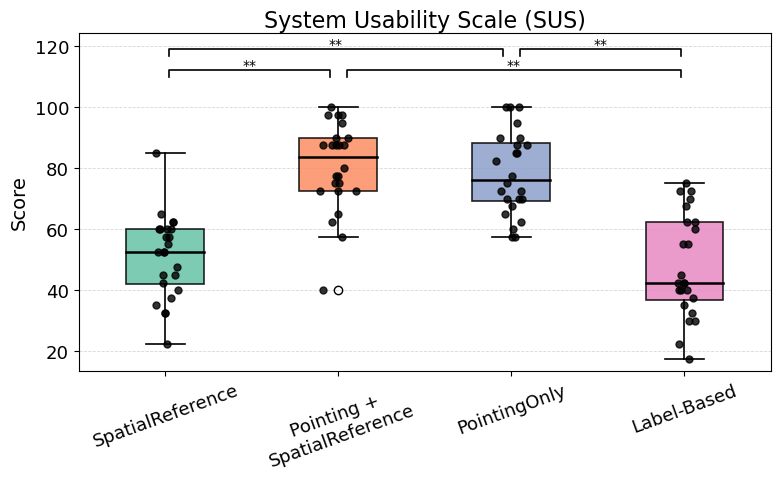

C:\Users\tenma\AppData\Local\Temp\ipykernel_50228\2302620081.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = [cm.get_cmap(cmap_name)(i) for i in range(len(labels))]


{'0.01': [('SR', 'P+SR'), ('SR', 'Pointing'), ('P+SR', 'Label'), ('Pointing', 'Label')], '0.05': []}


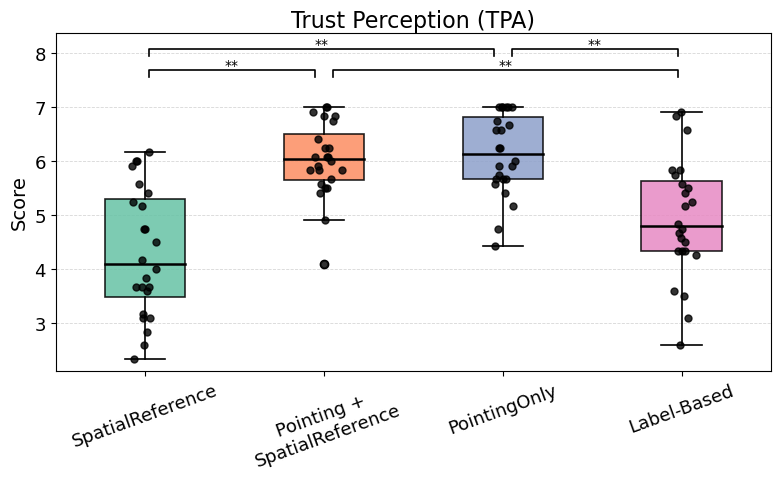

C:\Users\tenma\AppData\Local\Temp\ipykernel_50228\2302620081.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = [cm.get_cmap(cmap_name)(i) for i in range(len(labels))]


{'0.01': [('SR', 'P+SR'), ('SR', 'Pointing'), ('P+SR', 'Label'), ('Pointing', 'Label')], '0.05': []}


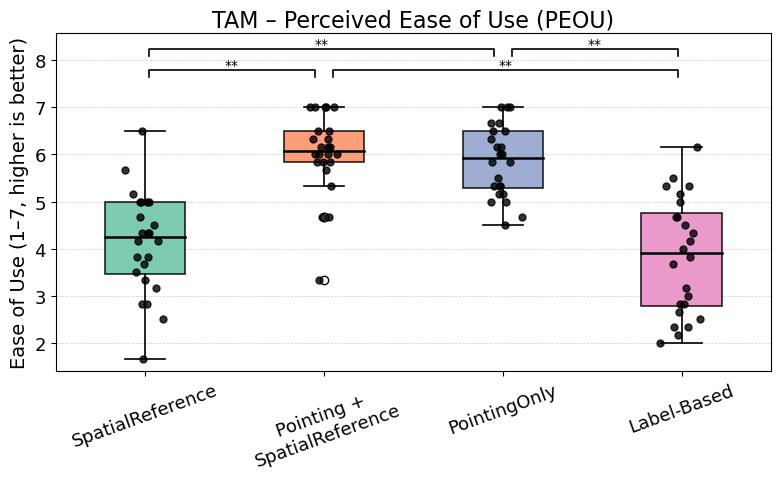

C:\Users\tenma\AppData\Local\Temp\ipykernel_50228\2302620081.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = [cm.get_cmap(cmap_name)(i) for i in range(len(labels))]


{'0.01': [('SR', 'P+SR'), ('P+SR', 'Label')], '0.05': []}


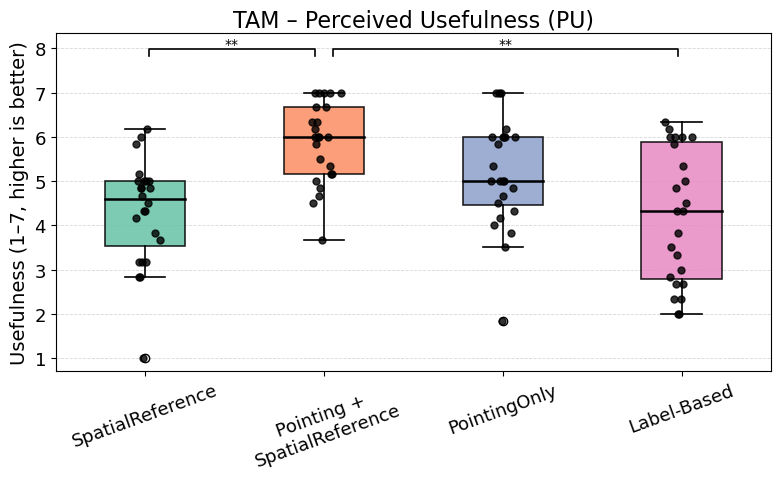

C:\Users\tenma\AppData\Local\Temp\ipykernel_50228\2302620081.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = [cm.get_cmap(cmap_name)(i) for i in range(len(labels))]


{'0.01': [('SR', 'P+SR'), ('SR', 'Pointing'), ('P+SR', 'Label'), ('Pointing', 'Label')], '0.05': []}


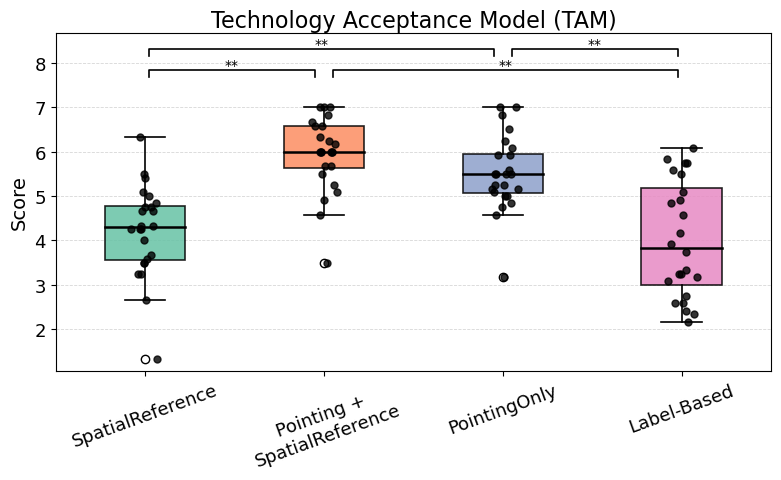

C:\Users\tenma\AppData\Local\Temp\ipykernel_50228\2302620081.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = [cm.get_cmap(cmap_name)(i) for i in range(len(labels))]


{'0.01': [('SR', 'P+SR'), ('SR', 'Pointing'), ('P+SR', 'Label'), ('Pointing', 'Label')], '0.05': []}


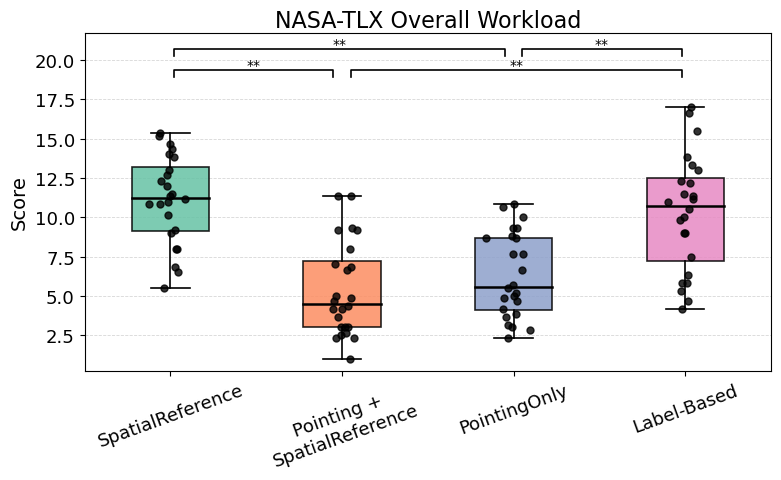

In [4]:
# --- 既存関数をそのまま使う描画セル ---
import matplotlib.pyplot as plt

SAVE_FIG = True

# ---- 統一スタイル ----
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

# === 表示ラベル ===
DISPLAY_LABELS = {
    "SR": "SpatialReference",
    "P+SR": "Pointing +\nSpatialReference",
    "Pointing": "PointingOnly",
    "Label": "Label-Based"
}

def _pretty_axes(ax, condition_order):
    ticklabels = [DISPLAY_LABELS[c] for c in condition_order]
    ax.set_xticklabels(ticklabels, rotation=20, ha="center")
    ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.margins(x=0.02)

# === 有意差ブラケット用マッピング ===
id_to_pos = {cid: i+1 for i, cid in enumerate(CONDITION_ORDER)}  # x位置は1-based

# --- ここで box_kwargs / bracket_kwargs が定義されてない場合は追加 ---
if "box_kwargs" not in locals():
    box_kwargs = {}
if "bracket_kwargs" not in locals():
    bracket_kwargs = {}

# ==================================================
# 1) SUS
# ==================================================
plt.figure(figsize=(8,5))
ax = plt.gca()
sus_lists = lists_by_condition(long_df, scale="SUS", subscale="Total")
boxplot_with_black_points(
    ax, sus_lists, CONDITION_ORDER,
    "System Usability Scale (SUS)",
    "Score",
    **box_kwargs
)
pairs = survey.significant_pairs(scale="SUS", subscale="Total")
add_sig_brackets(ax, pairs, id_to_pos, **bracket_kwargs)
_pretty_axes(ax, CONDITION_ORDER)
plt.tight_layout()
if SAVE_FIG:
    plt.savefig("./OUTPUT_IMG/SUS.png", dpi=300, bbox_inches="tight")
plt.show()

# ==================================================
# 2) Trust (TPA)
# ==================================================
plt.figure(figsize=(8,5))
ax = plt.gca()
tpa_lists = lists_by_condition(long_df, scale="TPA", subscale="Total")
boxplot_with_black_points(
    ax, tpa_lists, CONDITION_ORDER,
    "Trust Perception (TPA)",
    "Score",
    **box_kwargs
)
pairs = survey.significant_pairs(scale="TPA", subscale="Total")
add_sig_brackets(ax, pairs, id_to_pos, **bracket_kwargs)
_pretty_axes(ax, CONDITION_ORDER)
plt.tight_layout()
if SAVE_FIG:
    plt.savefig("./OUTPUT_IMG/TPA.png", dpi=300, bbox_inches="tight")
plt.show()

# ==================================================
# 3) TAM – Perceived Ease of Use (PEOU)
# ==================================================
plt.figure(figsize=(8,5))
ax = plt.gca()
tam_peou = lists_by_condition(long_df, scale="TAM", subscale="PEOU")
boxplot_with_black_points(
    ax, tam_peou, CONDITION_ORDER,
    "TAM – Perceived Ease of Use (PEOU)",
    "Ease of Use (1–7, higher is better)",
    **box_kwargs
)
pairs = survey.significant_pairs(scale="TAM", subscale="PEOU")
add_sig_brackets(ax, pairs, id_to_pos, **bracket_kwargs)
_pretty_axes(ax, CONDITION_ORDER)
plt.tight_layout()
if SAVE_FIG:
    plt.savefig("./OUTPUT_IMG/TAM_PEOU.png", dpi=300, bbox_inches="tight")
plt.show()

# ==================================================
# 4) TAM – Perceived Usefulness (PU)
# ==================================================
plt.figure(figsize=(8,5))
ax = plt.gca()
tam_pu = lists_by_condition(long_df, scale="TAM", subscale="PU")
boxplot_with_black_points(
    ax, tam_pu, CONDITION_ORDER,
    "TAM – Perceived Usefulness (PU)",
    "Usefulness (1–7, higher is better)",
    **box_kwargs
)
pairs = survey.significant_pairs(scale="TAM", subscale="PU")
add_sig_brackets(ax, pairs, id_to_pos, **bracket_kwargs)
_pretty_axes(ax, CONDITION_ORDER)
plt.tight_layout()
if SAVE_FIG:
    plt.savefig("./OUTPUT_IMG/TAM_PU.png", dpi=300, bbox_inches="tight")
plt.show()

# ==================================================
# 5) TAM – Total
# ==================================================
plt.figure(figsize=(8,5))
ax = plt.gca()
tam_total = lists_by_condition(long_df, scale="TAM", subscale="Total")
boxplot_with_black_points(
    ax, tam_total, CONDITION_ORDER,
    "Technology Acceptance Model (TAM)",
    "Score",
    **box_kwargs
)
pairs = survey.significant_pairs(scale="TAM", subscale="Total")
add_sig_brackets(ax, pairs, id_to_pos, **bracket_kwargs)
_pretty_axes(ax, CONDITION_ORDER)
plt.tight_layout()
if SAVE_FIG:
    plt.savefig("./OUTPUT_IMG/TAM.png", dpi=300, bbox_inches="tight")
plt.show()

# ==================================================
# 6) NASA-TLX Overall
# ==================================================
plt.figure(figsize=(8,5))
ax = plt.gca()
nasa_overall = lists_by_condition(long_df, scale="NASA-TLX", subscale="Overall")
boxplot_with_black_points(
    ax, nasa_overall, CONDITION_ORDER,
    "NASA-TLX Overall Workload",
    "Score",
    **box_kwargs
)
pairs = survey.significant_pairs(scale="NASA-TLX", subscale="Overall")
add_sig_brackets(ax, pairs, id_to_pos, **bracket_kwargs)
_pretty_axes(ax, CONDITION_ORDER)
plt.tight_layout()
if SAVE_FIG:
    plt.savefig("./OUTPUT_IMG/NASA_TLX.png", dpi=300, bbox_inches="tight")
plt.show()


In [5]:
sus_pairs = survey.significant_pairs(scale="SUS", subscale="Total")
print("SUS significant pairs:")
print(sus_pairs)


# TAM(Total)の有意ペア
tam_pairs_pu = survey.significant_pairs(scale="TAM", subscale="PU")
print("TAM significant pairs:")
print(tam_pairs_pu)


tam_pairs_peou = survey.significant_pairs(scale="TAM", subscale="PEOU")
print("TAM significant pairs:")
print(tam_pairs_peou)

# TrustTotal)の有意ペア
tam_pairs_pu = survey.significant_pairs(scale="TPA", subscale="Total")
print("TPA significant pairs:")
print(tam_pairs_pu)


# NASA-TLX(Overall)の有意ペア
nasatlx_pairs = survey.significant_pairs(scale="NASA-TLX", subscale="Overall")
print("NASA-TLX significant pairs:")
print(nasatlx_pairs)

SUS significant pairs:
{'0.01': [(1, 2), (1, 3), (2, 4), (3, 4)], '0.05': []}
TAM significant pairs:
{'0.01': [(1, 2), (2, 4)], '0.05': []}
TAM significant pairs:
{'0.01': [(1, 2), (1, 3), (2, 4), (3, 4)], '0.05': []}
TPA significant pairs:
{'0.01': [(1, 2), (1, 3), (2, 4), (3, 4)], '0.05': []}
NASA-TLX significant pairs:
{'0.01': [(1, 2), (1, 3), (2, 4), (3, 4)], '0.05': []}


# Order

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

# ========== Font setting (use only ASCII/English) ==========
plt.rcParams["font.family"] = "DejaVu Sans"  # default English-safe font
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({
    "font.size": 13,        # ベース
    "axes.titlesize": 16,   # 図タイトル
    "axes.labelsize": 14,   # 軸ラベル
    "xtick.labelsize": 13,  # 目盛り
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})
# ========== Load CSV ==========
df = pd.read_csv("./Order.csv", header=None)
df.columns = ["timestamp", "participant", "rank1", "rank2", "rank3", "rank4"]

# Trim spaces
for col in ["rank1", "rank2", "rank3", "rank4"]:
    df[col] = df[col].astype(str).str.strip()

# Rename to English abbreviations
rename_map = {
    "Pointing + 空間参照": "P+SR",
    "空間参照だけ": "Spatial",
    "Pointing": "Pointing",
    "Label": "Label"
}
for col in ["rank1", "rank2", "rank3", "rank4"]:
    df[col] = df[col].map(rename_map)

# Build rank score table
methods = ["P+SR", "Pointing", "Label", "Spatial"]
rank_scores = pd.DataFrame(index=df["participant"], columns=methods)

for _, row in df.iterrows():
    for i, method in enumerate([row["rank1"], row["rank2"], row["rank3"], row["rank4"]], start=1):
        if pd.notna(method):
            rank_scores.loc[row["participant"], method] = i

rank_scores = rank_scores.apply(pd.to_numeric, errors="coerce")

# ===== Mean rank =====
mean_ranks = rank_scores.mean().sort_values()

plt.figure(figsize=(6,4))
sns.barplot(x=mean_ranks.index, y=mean_ranks.values, palette="coolwarm")
plt.title("Average Rank (Lower = Better)", fontsize=13)
plt.ylabel("Mean Rank")
plt.xlabel("Interaction Method")
plt.ylim(1,4)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# ===== First choice count =====
first_choice_counts = df["rank1"].value_counts().reindex(methods, fill_value=0)

plt.figure(figsize=(6,4))
sns.barplot(x=first_choice_counts.index, y=first_choice_counts.values, palette="crest")
plt.title("Number of Participants Ranking 1st", fontsize=13)
plt.ylabel("Count")
plt.xlabel("Interaction Method")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# ===== Console output =====
print("Average Rank:\n", mean_ranks)
print("\nNumber of 1st-Place Votes:\n", first_choice_counts)




# dunn's test

FileNotFoundError: [Errno 2] No such file or directory: './Order.csv'

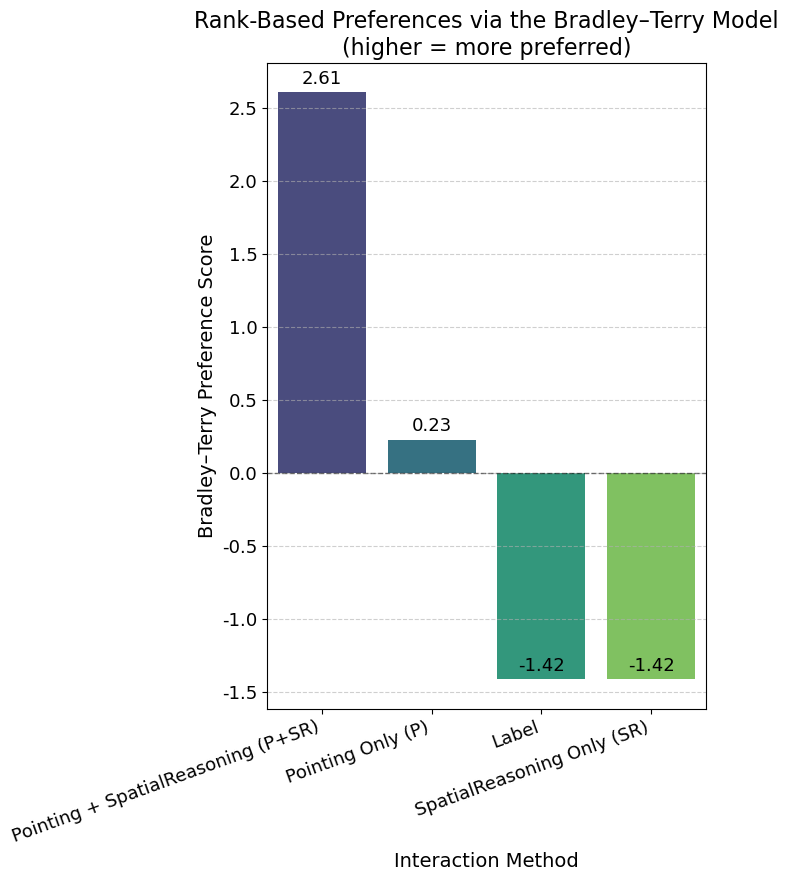


Bradley–Terry Estimated Scores (β) and Pairwise Win Probabilities

Pointing + SpatialReasoning (P+SR)        β=+2.605  |  P(P+SR>Pointing)=0.92  P(P+SR>Label)=0.98  P(P+SR>SR)=0.98
Pointing Only (P)                         β=+0.225  |  P(Pointing>P+SR)=0.08  P(Pointing>Label)=0.84  P(Pointing>SR)=0.84
Label                                     β=-1.415  |  P(Label>P+SR)=0.02  P(Label>Pointing)=0.16  P(Label>SR)=0.50
SpatialReasoning Only (SR)                β=-1.415  |  P(SR>P+SR)=0.02  P(SR>Pointing)=0.16  P(SR>Label)=0.50


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import choix  # for Bradley–Terry model fitting

SAVE_FIG = True

# ======== Load and preprocess ========
df = pd.read_csv("./ResultData/Order.csv", header=None)
df.columns = ["timestamp", "participant", "rank1", "rank2", "rank3", "rank4"]

# Trim spaces
for col in ["rank1", "rank2", "rank3", "rank4"]:
    df[col] = df[col].astype(str).str.strip()

# Define expected condition labels and mapping
rename_map = {
    "Pointing + 空間参照": "P+SR",
    "空間参照だけ": "SR",
    "Pointing": "Pointing",
    "Label": "Label",
}
valid_labels = list(rename_map.keys())

# Keep only valid labels and map them to English abbreviations
for col in ["rank1", "rank2", "rank3", "rank4"]:
    df[col] = df[col].where(df[col].isin(valid_labels), np.nan)
    df[col] = df[col].map(rename_map)

# Display labels (for plotting)
DISPLAY_LABELS = {
    "P+SR":    "Pointing + SpatialReasoning (P+SR)",
    "Pointing":"Pointing Only (P)",
    "Label":   "Label",
    "SR":      "SpatialReasoning Only (SR)",
}
methods = ["P+SR", "Pointing", "Label", "SR"]

# ======== Rank table ========
rank_scores = pd.DataFrame(index=df["participant"].astype(str).values, columns=methods)
for _, row in df.iterrows():
    for i, m in enumerate([row["rank1"], row["rank2"], row["rank3"], row["rank4"]], start=1):
        if pd.notna(m):
            rank_scores.loc[str(row["participant"]), m] = i
rank_scores = rank_scores.apply(pd.to_numeric, errors="coerce")

# ======== Pairwise outcomes ========
pairs = []
for _, row in rank_scores.iterrows():
    order = row.dropna().sort_values().index.tolist()  # best → worst
    for i in range(len(order)):
        for j in range(i + 1, len(order)):
            pairs.append((methods.index(order[i]), methods.index(order[j])))

# Add symmetric smoothing to stabilize the model
for i in range(len(methods)):
    for j in range(len(methods)):
        if i != j:
            pairs.append((i, j))

# ======== Fit Bradley–Terry model ========
abilities = choix.ilsr_pairwise(len(methods), pairs)
abilities = abilities - np.mean(abilities)  # mean-zero normalization

bt_df = pd.DataFrame({"Method": methods, "Ability": abilities})
bt_df["Display"] = bt_df["Method"].map(DISPLAY_LABELS)
bt_df = bt_df.sort_values("Ability", ascending=False).reset_index(drop=True)

# ======== Plot ========
plt.figure(figsize=(7.2, 9))
ax = sns.barplot(
    x="Display", y="Ability", data=bt_df,
    order=bt_df["Display"], palette="viridis"
)
ax.axhline(0, linestyle="--", linewidth=1, color="black", alpha=0.5)

# Add numeric annotations
for p in ax.patches:
    y = p.get_height()
    ax.annotate(f"{y:.2f}", (p.get_x() + p.get_width()/2, y),
                ha="center", va="bottom", fontsize=13, xytext=(0, 3),
                textcoords="offset points")

ax.set_title("Rank-Based Preferences via the Bradley–Terry Model\n(higher = more preferred)", fontsize=16)
ax.set_xlabel("Interaction Method")
ax.set_ylabel("Bradley–Terry Preference Score")

plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
if SAVE_FIG:
    plt.savefig("Bradley–Terry.png", dpi=300, bbox_inches="tight")
plt.show()

# ======== Print numerical results ========
def win_prob(beta_i, beta_j):
    return 1.0 / (1.0 + np.exp(beta_j - beta_i))

abilities_map = dict(zip(methods, abilities))

print("\nBradley–Terry Estimated Scores (β) and Pairwise Win Probabilities\n")
for m in bt_df["Method"]:
    beta = abilities_map[m]
    comps = []
    for ref in ["P+SR", "Pointing", "Label", "SR"]:
        if ref == m:
            continue
        comps.append(f"P({m}>{ref})={win_prob(beta, abilities_map[ref]):.2f}")
    print(f"{DISPLAY_LABELS[m]:40s}  β={beta:+.3f}  |  " + "  ".join(comps))


In [ ]:
!pip install choix